# Musterlösung Opt Teil

## Aufgabe 2b

### Generiert eine zufällige Beispiel-Instanz

In [1]:
import random

def generate_instance(n, K, max_machines,
                      p_min=1, p_max=20,
                      machines_min=2,
                      due_date_factor=1.3,
                      generate_due_dates=True,
                      seed=None):

    if seed is not None:
        random.seed(seed)

    # -------------------
    # Sets
    # -------------------

    I = list(range(n))
    P = list(range(K))

    # Workstations per phase (random)
    M = {}
    for k in P:
        num_machines = random.randint(machines_min, max_machines)
        M[k] = list(range(num_machines))

    # -------------------
    # Processing times p[i,k]
    # -------------------

    p = {}
    for i in I:
        for k in P:
            if random.random() < 0:
                p[i, k] = 0
            else:
                p[i, k] = random.randint(p_min, p_max)

    # -------------------
    # Due dates (optional)
    # -------------------

    d = None

    if generate_due_dates:
        d = {}
        for i in I:
            total_processing = sum(p[i, k] for k in P)
            d[i] = int(total_processing * random.uniform(1.0, due_date_factor))

    return I, P, M, p, d

In [2]:
n = 10
K = 3
max_machines = 3


I, P, M, p, d = generate_instance(n, K, max_machines, seed = 2)

BIGM = sum(p[i, k] for i in I for k in P)

### Implementierung des MILP in Gurobi + solve

In [ ]:
import gurobipy as gp
from gurobipy import GRB

# -------------------
# Sets (example structure)
# -------------------


# M[k] = list of machines in phase k
# Example: M = {0:[0,1], 1:[0], 2:[0,1,2]}

# -------------------
# Parameters
# -------------------

# p[(i,k)] = processing time
# d[i]     = due date
# BIGM     = large constant

# -------------------
# Model
# -------------------

model = gp.Model("FlowShopWithTardiness")

# -------------------
# Variables
# -------------------

# x[i,k,m] = 1 if job i on machine m in phase k
x = model.addVars(
    ((i, k, m) for i in I for k in P for m in M[k]),
    vtype=GRB.BINARY,
    name="x"
)

# y[i,j,k,m] = ordering variable
y = model.addVars(
    ((i, j, k, m)
     for i in I for j in I if i != j
     for k in P for m in M[k]),
    vtype=GRB.BINARY,
    name="y"
)

# Start times
S = model.addVars(
    ((i, k) for i in I for k in P),
    vtype=GRB.CONTINUOUS,
    lb=0,
    name="S"
)

# Tardiness
T = model.addVars(
    I,
    vtype=GRB.CONTINUOUS,
    lb=0,
    name="T"
)

# -------------------
# Objective
# -------------------

model.setObjective(
    gp.quicksum(T[i] for i in I),
    GRB.MINIMIZE
)

# -------------------
# Constraints
# -------------------

# (1) Assignment constraint
# sum_m x[i,k,m] = 1

for i in I:
    for k in P:
        model.addConstr(
            gp.quicksum(x[i, k, m] for m in M[k]) == 1,
            name=f"assign_{i}_{k}"
        )

# (2) Flow constraint between phases
# S[i,k] >= S[i,k-1] + p[i,k-1]

for i in I:
    for k in P[1:]:
        model.addConstr(
            S[i, k] >= S[i, k-1] + p[i, k-1],
            name=f"flow_{i}_{k}"
        )

# (3) Sequencing on same machine
# S[i,k] + p[i,k] <= S[j,k] + M*(1 - y[i,j,k,m])

for i in I:
    for j in I:
        if i != j:
            for k in P:
                for m in M[k]:
                    model.addConstr(
                        S[i, k] + p[i, k]
                        <= S[j, k] + BIGM * (1 - y[i, j, k, m]),
                        name=f"seq_{i}_{j}_{k}_{m}"
                    )

# (4) Linking y and x (machine conflict)
# y[i,j,k,m] + y[j,i,k,m] >= x[i,k,m] + x[j,k,m] - 1

for i in I:
    for j in I:
        if i < j:
            for k in P:
                for m in M[k]:
                    model.addConstr(
                        y[i, j, k, m] + y[j, i, k, m]
                        >= x[i, k, m] + x[j, k, m] - 1,
                        name=f"order_link_{i}_{j}_{k}_{m}"
                    )

# (5) Tardiness definition
# T[i] >= S[i,K-1] + p[i,K-1] - d[i]

last_phase = K - 1

for i in I:
    model.addConstr(
        T[i] >= S[i, last_phase] + p[i, last_phase] - d[i],
        name=f"tardiness_{i}"
    )

# -------------------
# Optimize
# -------------------

model.setParam('TimeLimit', 600)
model.optimize()

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2775578
Academic license 2775578 - for non-commercial use only - registered to ma___@tu-dortmund.de
Set parameter TimeLimit to value 600
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (linux64 - "Ubuntu 24.04.4 LTS")

CPU model: AMD EPYC Processor (with IBPB), instruction set [SSE2|AVX|AVX2]
Thread count: 32 physical cores, 32 logical processors, using up to 32 threads

Non-default parameters:
TimeLimit  600

Academic license 2775578 - for non-commercial use only - registered to ma___@tu-dortmund.de
Optimize a model with 870 rows, 640 columns and 2820 nonzeros (Min)
Model fingerprint: 0xa6d11a0b
Model has 10 linear objective coefficients
Variable types: 40 continuous, 600 integer (600 binary)
Coefficient statistics:
  Matrix range     [1e+00, 4e+02]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 4e+02]

Presolve removed 30 rows and 30 columns
Presolve tim

### Darstellungen des resultierenden Belegungsplan als Gantt Chart

Würde ich so nicht von den Studierenden fordern aber ist schön :)

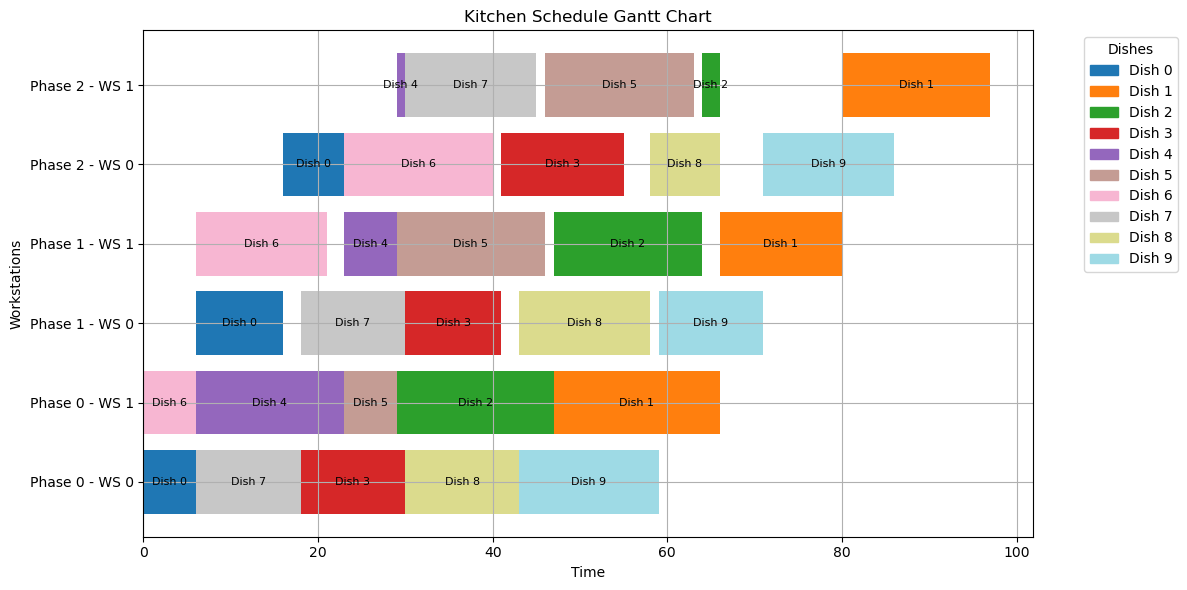

In [4]:
import matplotlib.pyplot as plt
import matplotlib

# -------------------
# PREPARE DATA
# -------------------

tasks = []

for i in I:
    for k in P:
        for m in M[k]:
            if x[i,k,m].X > 0.5:
                start = S[i,k].X
                duration = p[i,k]
                tasks.append((i, k, m, start, duration))

# Sort tasks by start time
tasks.sort(key=lambda x: x[3])

# Workstation labels
labels = []
y_pos = []

counter = 0
for k in P:
    for m in M[k]:
        labels.append(f"Phase {k} - WS {m}")
        y_pos.append(counter)
        counter += 1

# Mapping workstation → y-position
pos_map = {}
counter = 0
for k in P:
    for m in M[k]:
        pos_map[(k,m)] = counter
        counter += 1

# -------------------
# COLOR MAP (ONE COLOR PER DISH)
# -------------------

cmap = matplotlib.colormaps.get_cmap("tab20")  # modern way
dish_color = {i: cmap(i / max(1,len(I)-1)) for i in I}  # normalize to [0,1]

# -------------------
# PLOT
# -------------------

plt.figure(figsize=(12, 6))

for (i, k, m, start, duration) in tasks:
    plt.barh(
        pos_map[(k,m)],
        duration,
        left=start,
        color=dish_color[i]
    )

    plt.text(
        start + duration/2,
        pos_map[(k,m)],
        f"Dish {i}",
        va='center',
        ha='center',
        fontsize=8,
        color="black"
    )

# Axis formatting
plt.yticks(y_pos, labels)
plt.xlabel("Time")
plt.ylabel("Workstations")
plt.title("Kitchen Schedule Gantt Chart")

# -------------------
# LEGEND
# -------------------

handles = [
    plt.Rectangle((0,0),1,1, color=dish_color[i])
    for i in I
]

plt.legend(
    handles,
    [f"Dish {i}" for i in I],
    title="Dishes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(True)
plt.tight_layout()
plt.show()


## Aufgabe 2c Heuristiken

### Earliest Due date Dispatching

In [6]:
import numpy as np

def edd_greedy_heuristic_with_tardiness(I, P, M, p, d):
    """
    EDD dispatching + greedy machine allocation
    Calculates total tardiness
    """

    # -------------------
    # Sort jobs by due date (EDD)
    # -------------------
    I_edd = sorted(I, key=lambda i: d[i])

    # -------------------
    # Machine availability times
    # -------------------
    machine_time = {k: np.zeros(len(M[k])) for k in P}

    # -------------------
    # Start times and assignment
    # -------------------
    S = np.zeros((len(I), len(P)))  # start times
    x = {(i, k, m): 0 for i in I for k in P for m in M[k]}  # machine assignment

    # -------------------
    # Schedule loop
    # -------------------
    for k in P:
        for i in I_edd:

            # Job ready time
            if k > 0:
                job_ready = S[i, k-1] + p[i, k-1]
            else:
                job_ready = 0

            # Skip zero-time phases
            if p[i, k] == 0:
                S[i, k] = job_ready
                continue

            # Greedy machine choice
            m_idx = np.argmin(machine_time[k])
            start = max(machine_time[k][m_idx], job_ready)

            # Assign
            x[i, k, M[k][m_idx]] = 1
            S[i, k] = start

            # Update machine availability
            machine_time[k][m_idx] = start + p[i, k]

    # -------------------
    # Total tardiness
    # -------------------
    total_tardiness = 0
    for i in I:
        completion_time = S[i, P[-1]] + p[i, P[-1]]  # last phase completion
        tardiness = max(0, completion_time - d[i])
        total_tardiness += tardiness

    print(f"Total tardiness: {total_tardiness}")

    return x, S, total_tardiness


In [7]:
import matplotlib.pyplot as plt


def heuristics_gantt_chart(I, P, M, S, p, x, title="EDD Greedy Heuristic – Gantt Chart"):
    """
    Plot a Gantt chart for a set of jobs, phases, and workstations.

    Parameters
    ----------
    I : list
        List of job indices
    P : list
        List of phases
    M : dict
        Mapping from phase k to list of workstations M[k]
    S : dict
        Mapping from (i,k) to start time of job i in phase k
    p : dict
        Mapping from (i,k) to processing time of job i in phase k
    x : dict
        Mapping from (i,k,m) to 1 if job i is assigned to workstation m in phase k
    title : str, optional
        Title of the plot (default is "EDD Greedy Heuristic – Gantt Chart")
    """
    
    # -------------------
    # PREPARE DATA
    # -------------------
    
    tasks = []
    for i in I:
        for k in P:
            if p[i, k] == 0:
                continue  # no machine used
            for m in M[k]:
                if x[i, k, m] == 1:
                    start = S[i, k]
                    duration = p[i, k]
                    tasks.append((i, k, m, start, duration))
    
    tasks.sort(key=lambda x: x[3])  # sort by start time
    
    # -------------------
    # Workstation labels
    # -------------------
    
    labels = []
    y_pos = []
    counter = 0
    for k in P:
        for m in M[k]:
            labels.append(f"Phase {k} - WS {m}")
            y_pos.append(counter)
            counter += 1
    
    # Mapping workstation → y-position
    pos_map = {(k, m): idx for idx, (k, m) in enumerate([(k, m) for k in P for m in M[k]])}
    
    # -------------------
    # COLOR MAP (ONE COLOR PER JOB)
    # -------------------
    
    cmap = matplotlib.colormaps.get_cmap("tab20")
    job_color = {i: cmap(i / max(1, len(I) - 1)) for i in I}
    
    # -------------------
    # PLOT
    # -------------------
    
    plt.figure(figsize=(12, 6))
    
    for (i, k, m, start, duration) in tasks:
        plt.barh(
            pos_map[(k, m)],
            duration,
            left=start,
            color=job_color[i]
        )
        plt.text(
            start + duration / 2,
            pos_map[(k, m)],
            f"Job {i}",
            va="center",
            ha="center",
            fontsize=8,
            color="black"
        )
    
    plt.yticks(y_pos, labels)
    plt.xlabel("Time")
    plt.ylabel("Workstations")
    plt.title(title)
    
    # -------------------
    # LEGEND
    # -------------------
    
    handles = [plt.Rectangle((0, 0), 1, 1, color=job_color[i]) for i in I]
    plt.legend(
        handles,
        [f"Job {i}" for i in I],
        title="Jobs",
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )
    
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [8]:
x, S, tardiness = edd_greedy_heuristic_with_tardiness(I, P, M, p, d)

Total tardiness: 215.0


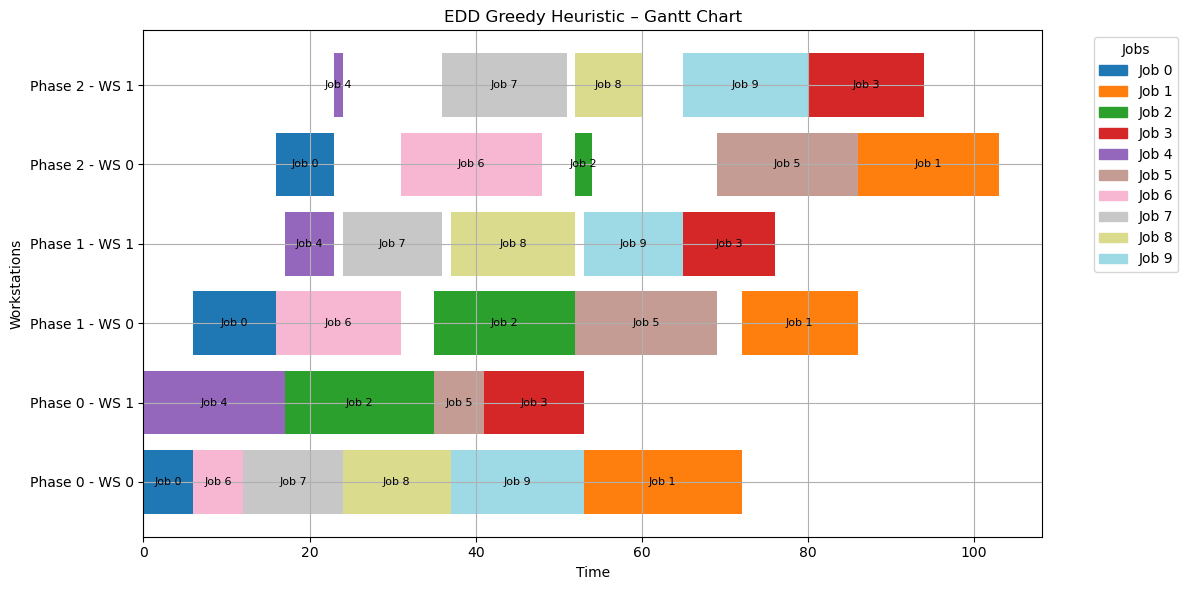

In [9]:
heuristics_gantt_chart(I, P, M, S, p, x, title="EDD Greedy Heuristic – Gantt Chart")

In [10]:
import numpy as np

def edd_greedy_heuristic_reduce_idle(I, P, M, p, d):
    """
    EDD dispatching + modified greedy allocation to reduce machine idle time.
    - Normally pick earliest available machine
    - If job is not ready yet and some machines are already free before job_ready,
      pick the one that became free last to reduce idling.
    Calculates total tardiness.
    """

    # -------------------
    # Sort jobs by due date (EDD)
    # -------------------
    I_edd = sorted(I, key=lambda i: d[i])

    # -------------------
    # Machine availability times
    # -------------------
    machine_time = {k: np.zeros(len(M[k])) for k in P}

    # -------------------
    # Start times and assignment
    # -------------------
    S = np.zeros((len(I), len(P)))  # start times
    x = {(i, k, m): 0 for i in I for k in P for m in M[k]}  # machine assignment

    # -------------------
    # Schedule loop
    # -------------------
    for k in P:
        for i in I_edd:

            # Job ready time
            if k > 0:
                job_ready = S[i, k-1] + p[i, k-1]
            else:
                job_ready = 0

            # Skip zero-time phases
            if p[i, k] == 0:
                S[i, k] = job_ready
                continue

            mtimes = machine_time[k]

            # Machines that are free before job is ready
            ready_machines = [idx for idx, t in enumerate(mtimes) if t <= job_ready]

            if ready_machines:
                # Pick the machine that became free **last** (largest mtimes)
                m_idx = ready_machines[np.argmax([mtimes[idx] for idx in ready_machines])]
            else:
                # All machines busy past job_ready → pick earliest finishing
                m_idx = np.argmin(mtimes)

            # Actual start time
            start = max(mtimes[m_idx], job_ready)

            # Assign
            x[i, k, M[k][m_idx]] = 1
            S[i, k] = start

            # Update machine availability
            machine_time[k][m_idx] = start + p[i, k]

    # -------------------
    # Total tardiness
    # -------------------
    total_tardiness = 0
    for i in I:
        completion_time = S[i, P[-1]] + p[i, P[-1]]
        tardiness = max(0, completion_time - d[i])
        total_tardiness += tardiness

    print(f"Total tardiness: {total_tardiness}")

    return x, S, total_tardiness


In [11]:
x, S, tardiness = edd_greedy_heuristic_reduce_idle(I, P, M, p, d)

Total tardiness: 211.0


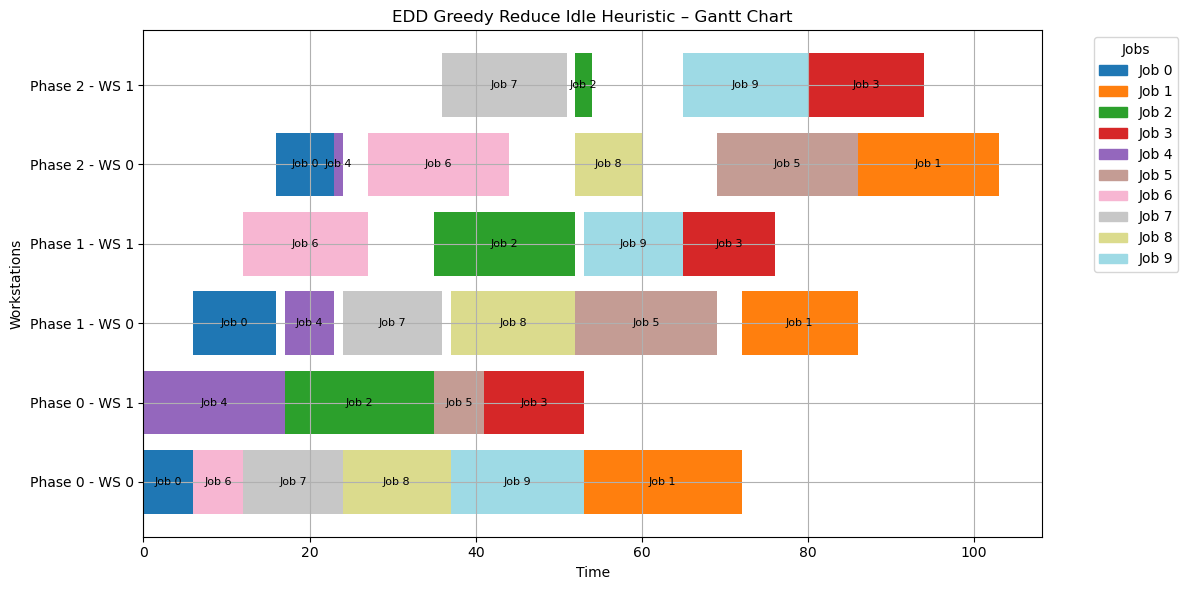

In [12]:
heuristics_gantt_chart(I, P, M, S, p, x, title="EDD Greedy Reduce Idle Heuristic – Gantt Chart")

In [13]:
import numpy as np

def max_due_completion_greedy(I, P, M, p, d):
    """
    Greedy heuristic with:
    - Dispatching based on min(max(due date, earliest completion))
    - Reduce idle time machine allocation
    Calculates total tardiness.
    """

    n = len(I)
    K = len(P)

    # -------------------
    # Machine availability
    # -------------------
    machine_time = {k: np.zeros(len(M[k])) for k in P}

    # -------------------
    # Start times and assignment
    # -------------------
    S = np.zeros((n, K))
    x = {(i, k, m): 0 for i in I for k in P for m in M[k]}

    # Convert due dates dict to array
    d_array = np.array([d[i] for i in I])

    # -------------------
    # Phase by phase scheduling
    # -------------------
    for k in P:

        # Job ready times
        job_ready = np.array([S[i, k-1] + p[i, k-1] if k > 0 else 0 for i in I])

        # Remaining processing time from this phase onward
        remaining_p = np.array([sum(p[i, l] for l in P[k:]) for i in I])

        # Earliest possible completion time if scheduled immediately
        earliest_completion = job_ready + remaining_p

        # Priority = max(due date, earliest completion)
        priority = np.maximum(d_array, earliest_completion)

        # Sort jobs by smallest priority first
        I_priority = [i for i in np.argsort(priority)]

        # Schedule jobs in this order
        for i in I_priority:

            # Skip zero-time phases
            if p[i, k] == 0:
                S[i, k] = job_ready[i]
                continue

            mtimes = machine_time[k]

            # Machines free before job ready
            ready_machines = [idx for idx, t in enumerate(mtimes) if t <= job_ready[i]]

            if ready_machines:
                # Pick machine that became free last to reduce idle
                m_idx = ready_machines[np.argmax([mtimes[idx] for idx in ready_machines])]
            else:
                # All machines busy past job_ready → pick earliest finishing
                m_idx = np.argmin(mtimes)

            # Actual start time
            start = max(mtimes[m_idx], job_ready[i])
            S[i, k] = start
            x[i, k, M[k][m_idx]] = 1

            # Update machine availability
            machine_time[k][m_idx] = start + p[i, k]

    # -------------------
    # Total tardiness
    # -------------------
    total_tardiness = 0
    for i in I:
        completion_time = S[i, P[-1]] + p[i, P[-1]]
        total_tardiness += max(0, completion_time - d[i])

    print(f"Total tardiness: {total_tardiness}")

    return x, S, total_tardiness


In [14]:
x, S, tardiness = max_due_completion_greedy(I, P, M, p, d)

Total tardiness: 209.0


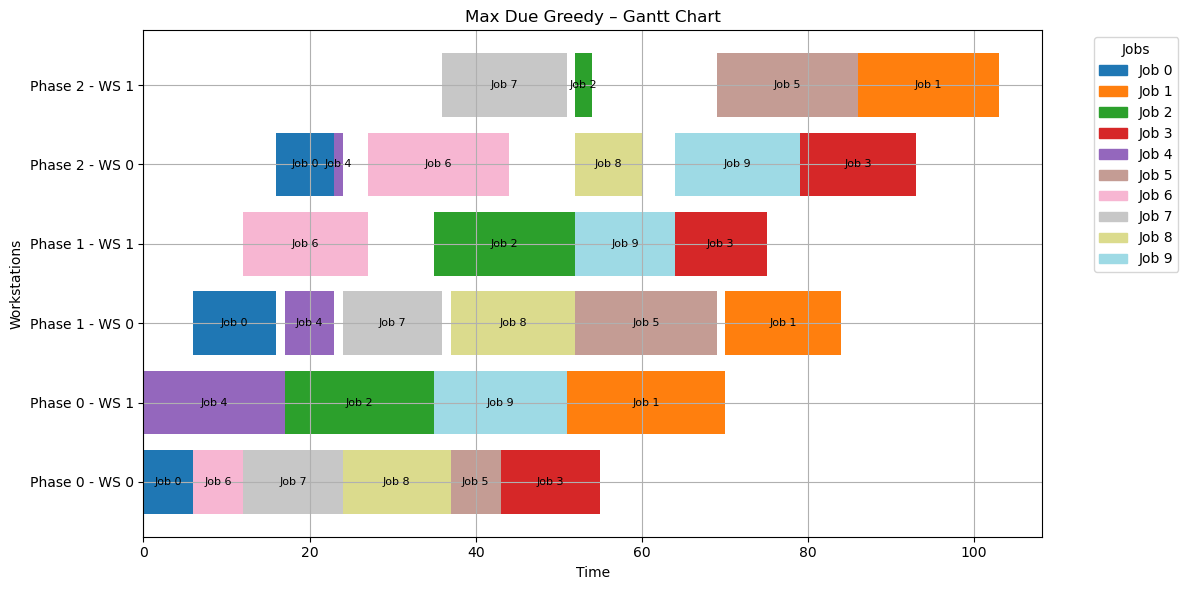

In [15]:
heuristics_gantt_chart(I, P, M, S, p, x, title="Max Due Greedy – Gantt Chart")

In [16]:
def edd_greedy_with_insertion_time_limit(I, P, M, p, d, max_time=60.0):
    """
    EDD dispatching + modified greedy allocation to reduce machine idle time
    + Insertion local search with a time limit (max_time in seconds).
    """
    import numpy as np
    import copy
    import time

    start_time = time.time()

    # -------------------
    # Startlösung: EDD + Modified Greedy
    # -------------------
    def schedule(order):
        machine_time = {k: np.zeros(len(M[k])) for k in P}
        S = np.zeros((len(I), len(P)))
        x = {(i, k, m): 0 for i in I for k in P for m in M[k]}

        for k in P:
            for i in order:
                job_ready = S[i, k-1] + p[i, k-1] if k > 0 else 0
                if p[i, k] == 0:
                    S[i, k] = job_ready
                    continue

                mtimes = machine_time[k]
                ready_machines = [idx for idx, t in enumerate(mtimes) if t <= job_ready]
                if ready_machines:
                    m_idx = ready_machines[np.argmax([mtimes[idx] for idx in ready_machines])]
                else:
                    m_idx = np.argmin(mtimes)

                start = max(mtimes[m_idx], job_ready)
                x[i, k, M[k][m_idx]] = 1
                S[i, k] = start
                machine_time[k][m_idx] = start + p[i, k]

        total_tardiness = sum(max(0, S[i, P[-1]] + p[i, P[-1]] - d[i]) for i in I)
        return x, S, total_tardiness

    # Initiale Reihenfolge nach EDD
    order = sorted(I, key=lambda i: d[i])
    x_best, S_best, tardiness_best = schedule(order)

    # -------------------
    # Insertion Local Search mit Zeitlimit
    # -------------------
    improved = True

    while improved and (time.time() - start_time < max_time):
        improved = False

        for i in range(len(order)):
            for j in range(len(order)):
                if i == j:
                    continue
                new_order = copy.deepcopy(order)
                # Insertion: Gericht i an Position j verschieben
                job = new_order.pop(i)
                new_order.insert(j, job)

                _, _, tardiness_new = schedule(new_order)

                if tardiness_new < tardiness_best:
                    order = new_order
                    tardiness_best = tardiness_new
                    x_best, S_best = schedule(order)[:2]
                    improved = True
                    break  # First Improvement
            if improved or (time.time() - start_time >= max_time):
                break

    print(f"Total tardiness: {tardiness_best}")
    return x_best, S_best, tardiness_best

In [17]:
x, S, tardiness = edd_greedy_with_insertion_time_limit(I, P, M, p, d)

Total tardiness: 162.0


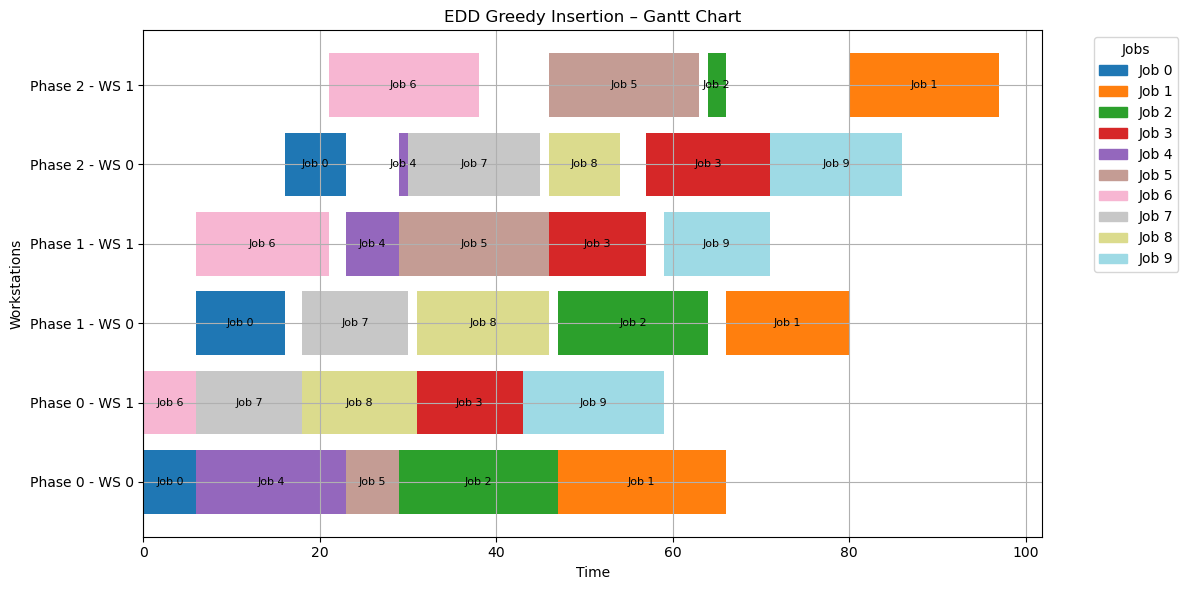

In [19]:
heuristics_gantt_chart(I, P, M, S, p, x, title="EDD Greedy Insertion – Gantt Chart")